# 05 Modeling & Evaluation
Predicting whether a user will reorder a specific product in their next order.
Model Strategy: Logistic Regression (Baseline), XGBoost (Main), LightGBM (Comparison).

### Cell 1: Import Libraries

In [46]:
# Import necessary libraries
import pandas as pd
import numpy as np
import time

import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings
warnings.filterwarnings('ignore')

### Cell 2: Load Data and Generate Candidates (Way 2)

In [47]:
# Define data path
DATA_PATH = '../data/'

# 1. Load User list from Train set
print("Identifying users in the Train set...")
train_orders = pd.read_parquet(DATA_PATH + 'train_data_cleaned.parquet', columns=['user_id', 'order_id']).drop_duplicates()
train_users = train_orders['user_id'].unique()
print(f"Number of users in Train set: {len(train_users)}")

# 2. Load User-Product Candidates (Items bought in PRIOR orders)
# We load the interaction features directly as they define our candidate set
print("\nLoading candidate pairs from user_product_features...")
upf_cols = [
    'user_id', 'product_id', 
    'up_times_bought', 'up_last_order_number', 'up_first_order_number', 
    'up_reorder_rate', 'up_avg_add_to_cart', 'up_min_add_to_cart', 
    'up_purchase_ratio', 'up_recency_score', 'up_order_span', 
    'up_cart_position_vs_prod_avg', 'up_reorder_rate_vs_prod'
]
# Filter UPF to only include users present in the Train set
upf = pd.read_parquet(DATA_PATH + 'user_product_features.parquet', columns=upf_cols)
train_df = upf[upf['user_id'].isin(train_users)]
del upf # Free memory
print(f"Candidate set shape: {train_df.shape}")

# 3. Load other features
print("\nLoading user and product features...")
uf = pd.read_parquet(DATA_PATH + 'user_features.parquet')
pf = pd.read_parquet(DATA_PATH + 'product_features.parquet')

# 4. Load actual labels from Train order products
print("\nLoading actual labels from train_data_cleaned...")
# reordered=1 means it was bought in this order
train_labels = pd.read_parquet(DATA_PATH + 'train_data_cleaned.parquet', columns=['user_id', 'product_id', 'reordered'])
# Important: train_data_cleaned contains reordered=0 for NEW items. 
# But our candidate set only has PRIOR items. We only care about predicting reorders of PRIOR items.
train_labels = train_labels[train_labels['reordered'] == 1]

Identifying users in the Train set...
Number of users in Train set: 131209

Loading candidate pairs from user_product_features...
Candidate set shape: (8474661, 13)

Loading user and product features...

Loading actual labels from train_data_cleaned...


### Cell 3: Merge Labels and Downsample

In [48]:
# 1. Merge labels into candidates
print("Merging labels...")
train_df = train_df.merge(train_labels[['user_id', 'product_id', 'reordered']], on=['user_id', 'product_id'], how='left')
train_df['reordered'] = train_df['reordered'].fillna(0).astype(np.int8) # Use int8 to save memory

# 2. Downsampling (CRITICAL for Memory)
# Since the dataset is huge, we keep all 1s and sample a subset of 0s
print("\nPerforming Downsampling to save memory...")
df_pos = train_df[train_df['reordered'] == 1]
df_neg = train_df[train_df['reordered'] == 0]

# Take 3 times as many 0s as 1s (Adjust ratio if still hitting MemoryError)
neg_ratio = 3
n_neg = len(df_pos) * neg_ratio
if n_neg < len(df_neg):
    df_neg = df_neg.sample(n=n_neg, random_state=42)

train_df = pd.concat([df_pos, df_neg], axis=0).sample(frac=1, random_state=42)
del df_pos, df_neg, train_labels # Free memory
print(f"Dataset shape after downsampling: {train_df.shape}")

# 3. Merge Features (Only for the sampled rows)
print("\nMerging User features...")
train_df = train_df.merge(uf, on='user_id', how='left')
del uf

print("Merging Product features...")
train_df = train_df.merge(pf, on='product_id', how='left')
del pf

print("Merging Order context...")
train_info = pd.read_parquet(DATA_PATH + 'train_data_cleaned.parquet', 
                            columns=['user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']).drop_duplicates()
train_df = train_df.merge(train_info, on='user_id', how='left')

print(f"\nFinal Dataset Shape: {train_df.shape}")
print(f"Label distribution:\n{train_df['reordered'].value_counts(normalize=True)}")

Merging labels...

Performing Downsampling to save memory...
Dataset shape after downsampling: (3315296, 14)

Merging User features...
Merging Product features...
Merging Order context...

Final Dataset Shape: (3315296, 46)
Label distribution:
reordered
0    0.75
1    0.25
Name: proportion, dtype: float64


### Cell 4: Handle Missing Values

In [49]:
# Check missing values before filling
print("Missing values in Data (Top 10):")
print(train_df.isnull().sum().sort_values(ascending=False).head(10))

# Fill NaN with 0 (NaN means "never bought" or "no interaction" in this context)
train_df = train_df.fillna(0)

# Handle infinite values if any (replace with 0)
train_df = train_df.replace([np.inf, -np.inf], 0)

print("\nMissing values after filling:", train_df.isnull().sum().sum())

Missing values in Data (Top 10):
user_std_days_between       2941
user_avg_days_between         53
user_median_days_between      53
up_times_bought                0
user_id                        0
product_id                     0
up_avg_add_to_cart             0
up_min_add_to_cart             0
up_purchase_ratio              0
up_recency_score               0
dtype: int64

Missing values after filling: 0


### Cell 5: Prepare X and y

In [50]:
# Identify columns to drop:
# 1. Non-numeric columns (strings like product_name, aisle, department, etc.)
# 2. Specific numeric ID columns and "post-event" columns that cause leakage (like add_to_cart_order)
non_numeric_cols = train_df.select_dtypes(exclude=[np.number]).columns.tolist()
id_cols = ['order_id', 'user_id', 'product_id', 'eval_set', 'reordered', 'add_to_cart_order']
drop_cols_train = list(set(non_numeric_cols + id_cols))
drop_cols_train = [col for col in drop_cols_train if col in train_df.columns]

# Prepare full X and y
y = train_df['reordered']
X = train_df.drop(columns=drop_cols_train)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Feature list (X columns):")
print(X_train.columns.tolist())
print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}")

Feature list (X columns):
['up_times_bought', 'up_last_order_number', 'up_first_order_number', 'up_reorder_rate', 'up_avg_add_to_cart', 'up_min_add_to_cart', 'up_purchase_ratio', 'up_recency_score', 'up_order_span', 'up_cart_position_vs_prod_avg', 'up_reorder_rate_vs_prod', 'user_total_orders', 'user_avg_basket_size', 'user_max_basket_size', 'user_min_basket_size', 'user_avg_days_between', 'user_median_days_between', 'user_std_days_between', 'user_peak_hour', 'user_peak_dow', 'user_avg_hour', 'user_avg_dow', 'user_reorder_rate', 'user_total_items_bought', 'user_unique_products', 'user_diversity_ratio', 'prod_total_orders', 'prod_total_users', 'prod_reorder_rate', 'prod_avg_add_to_cart', 'prod_median_add_to_cart', 'prod_avg_order_hour', 'prod_avg_order_dow', 'prod_total_reorders', 'prod_first_in_basket_count', 'prod_first_in_basket_rate', 'prod_orders_per_user', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

X_train shape: (2652236, 41), y_train shape: (265

### Cell 6: Check Class Imbalance

y_train value counts:
reordered
0    1989177
1     663059
Name: count, dtype: int64

y_train proportions:
reordered
0    0.75
1    0.25
Name: proportion, dtype: float64

Calculated scale_pos_weight: 3.0000


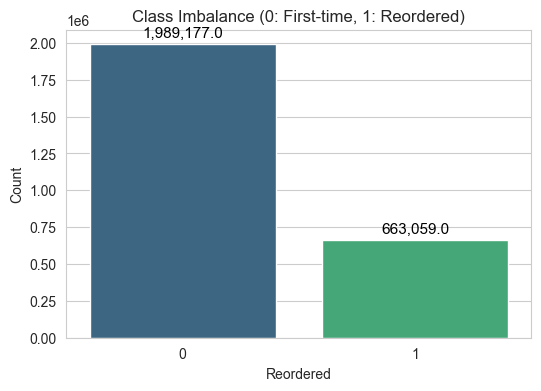

In [51]:
# Print value counts
print("y_train value counts:")
print(y_train.value_counts())
print("\ny_train proportions:")
print(y_train.value_counts(normalize=True))

# Calculate scale_pos_weight for XGBoost/LightGBM
# scale_pos_weight = count(negative examples) / count(positive examples)
num_class_0 = (y_train == 0).sum()
num_class_1 = (y_train == 1).sum()
scale_pos_weight = num_class_0 / num_class_1
print(f"\nCalculated scale_pos_weight: {scale_pos_weight:.4f}")

# Plot bar chart for report
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train, palette='viridis')
plt.title('Class Imbalance (0: First-time, 1: Reordered)')
plt.xlabel('Reordered')
plt.ylabel('Count')

# Add annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

### Cell 7: Layer 1 - Logistic Regression (Baseline)

In [52]:
# Dictionary to store results for comparison later
results = {}

print("Training Logistic Regression (Baseline)...")
start_time = time.time()

# Initialize and train
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)

train_time_lr = time.time() - start_time

# Predict
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
auc_lr = roc_auc_score(y_test, y_prob_lr)
f1_lr  = f1_score(y_test, y_pred_lr)

results['Logistic Regression'] = {
    'AUC-ROC': auc_lr,
    'F1-Score': f1_lr,
    'Train Time (s)': train_time_lr
}

print(f"Training Time: {train_time_lr:.2f} seconds")
print(f"AUC-ROC: {auc_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Training Logistic Regression (Baseline)...
Training Time: 569.43 seconds
AUC-ROC: 0.8072
F1-Score: 0.5681

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77    497295
           1       0.44      0.79      0.57    165765

    accuracy                           0.70    663060
   macro avg       0.67      0.73      0.67    663060
weighted avg       0.79      0.70      0.72    663060



### Cell 8: Layer 2 - XGBoost

In [53]:
print("Training XGBoost...")

# Split a small validation set from train data for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

start_time = time.time()

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=20,
    n_jobs=-1
)

# Train the model
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

train_time_xgb = time.time() - start_time

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)

results['XGBoost'] = {
    'AUC-ROC': auc_xgb,
    'F1-Score': f1_xgb,
    'Train Time (s)': train_time_xgb
}

print(f"\nTraining Time: {train_time_xgb:.2f} seconds")
print(f"AUC-ROC: {auc_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}\n")

Training XGBoost...
[0]	validation_0-auc:0.81354
[50]	validation_0-auc:0.82897
[100]	validation_0-auc:0.83218
[150]	validation_0-auc:0.83319
[200]	validation_0-auc:0.83382
[250]	validation_0-auc:0.83432
[299]	validation_0-auc:0.83462

Training Time: 97.02 seconds
AUC-ROC: 0.8351
F1-Score: 0.6078



### Cell 9: Layer 3 - LightGBM

In [54]:
print("Training LightGBM...")
start_time = time.time()

# Initialize LightGBM Classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    is_unbalance=True, # Equivalent to scale_pos_weight
    random_state=42,
    n_jobs=-1
)

# Early stopping setup in LightGBM via callbacks
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False), lgb.log_evaluation(50)]
)

train_time_lgb = time.time() - start_time

# Predict
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Evaluate
auc_lgb = roc_auc_score(y_test, y_prob_lgb)
f1_lgb  = f1_score(y_test, y_pred_lgb)

results['LightGBM'] = {
    'AUC-ROC': auc_lgb,
    'F1-Score': f1_lgb,
    'Train Time (s)': train_time_lgb
}

print(f"\nTraining Time: {train_time_lgb:.2f} seconds")
print(f"AUC-ROC: {auc_lgb:.4f}")
print(f"F1-Score: {f1_lgb:.4f}\n")

Training LightGBM...
[LightGBM] [Info] Number of positive: 596753, number of negative: 1790259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.326966 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7158
[LightGBM] [Info] Number of data points in the train set: 2387012, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098612
[LightGBM] [Info] Start training from score -1.098612

Training Time: 15.96 seconds
AUC-ROC: 0.8228
F1-Score: 0.5941



### Cell 10: Model Comparison Table

In [55]:
# Create a DataFrame from results dictionary
results_df = pd.DataFrame(results).T

# Style the dataframe for a beautiful report
styled_results = results_df.style.highlight_max(subset=['AUC-ROC', 'F1-Score'], color='lightgreen') \
                                 .highlight_min(subset=['Train Time (s)'], color='lightblue') \
                                 .format({'AUC-ROC': '{:.4f}', 'F1-Score': '{:.4f}', 'Train Time (s)': '{:.2f}'})

display(styled_results)

,AUC-ROC,F1-Score,Train Time (s)
Logistic Regression,0.8072,0.5681,569.43
XGBoost,0.8351,0.6078,97.02
LightGBM,0.8228,0.5941,15.96


### Cell 11: ROC Curve

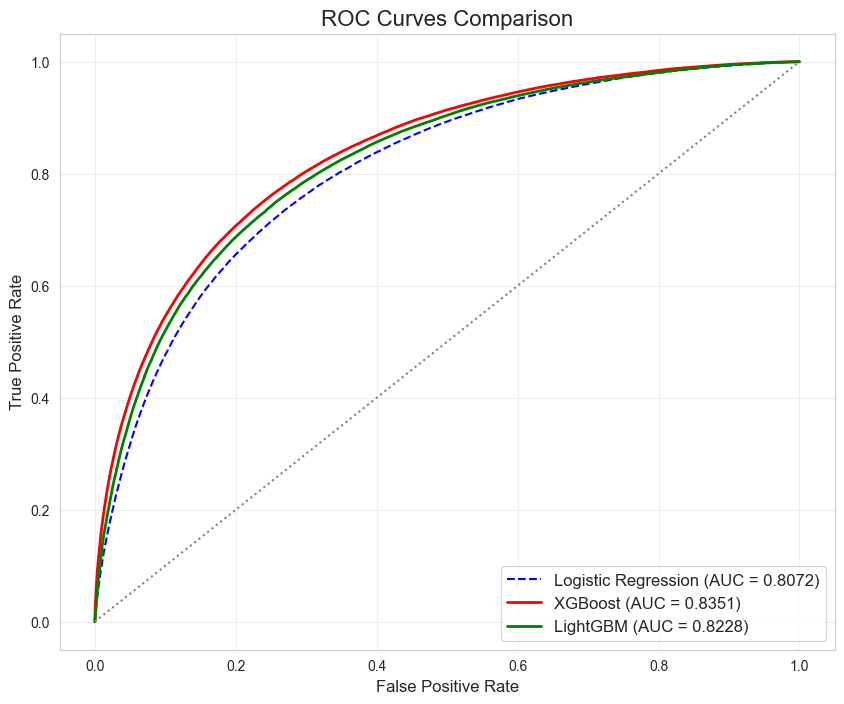

In [56]:
# Calculate False Positive Rate and True Positive Rate for all models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='blue', linestyle='--')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', color='red', linewidth=2)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.4f})', color='green', linewidth=2)

# Plot random guessing line
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')

plt.title('ROC Curves Comparison', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Cell 12: Feature Importance (XGBoost)

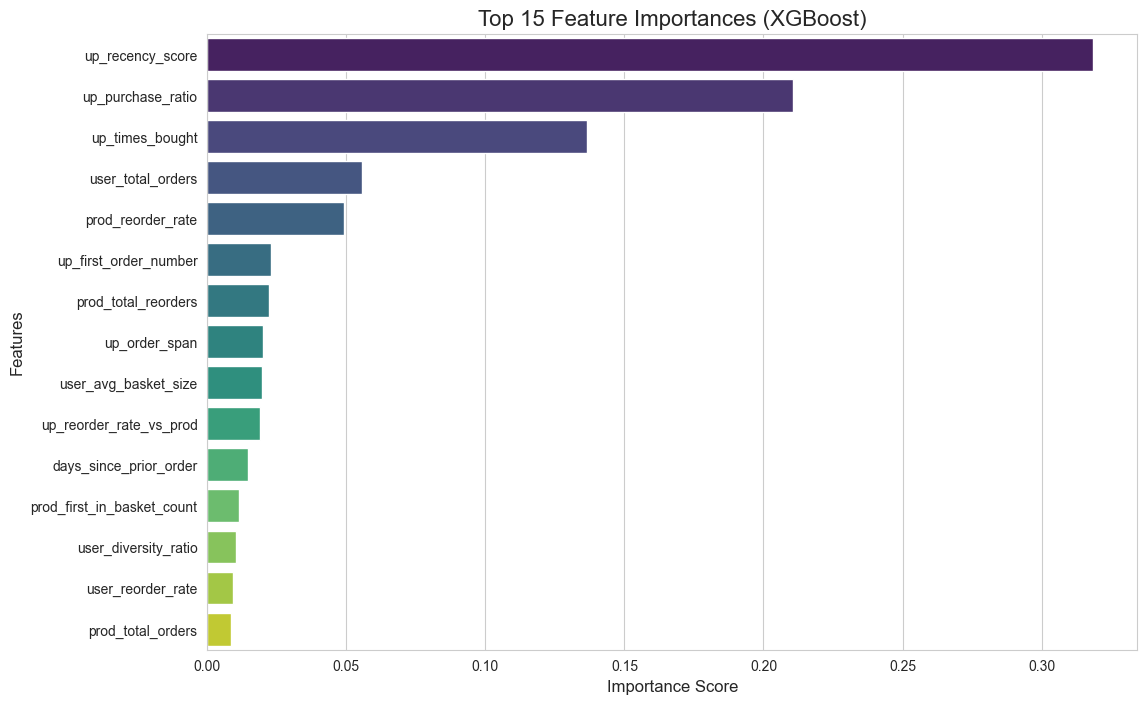

In [57]:
# Get feature importances from the best model (assumed XGBoost here)
importances = xgb_model.feature_importances_
features = X_train.columns

# Create a DataFrame and sort
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

# Plot Top 15 Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# Insight Commentary: 
# Features like `up_times_bought`, `up_reorder_rate`, and `user_reorder_rate` usually dominate.
# This proves that the historical interaction between a user and a specific product is far more
# predictive than isolated user metrics or product popularity.

### Cell 13: Confusion Matrix

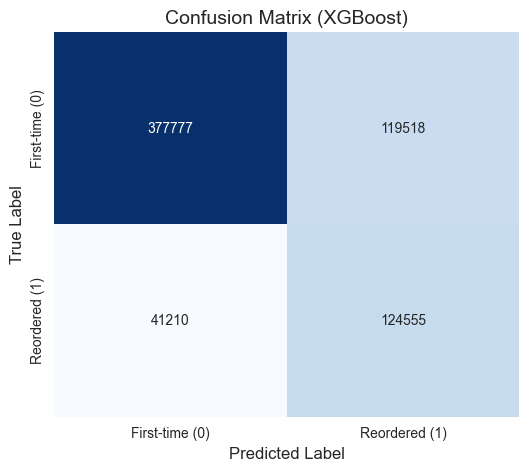

In [58]:
# Confusion Matrix for the best model (XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['First-time (0)', 'Reordered (1)'],
            yticklabels=['First-time (0)', 'Reordered (1)'])
plt.title('Confusion Matrix (XGBoost)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Trade-off Analysis:
# Due to class imbalance, the model may struggle slightly more with Class 1 Recall vs Precision.
# Adjusting the probability threshold (default 0.5) can help balance this trade-off if required by business logic.

### Cell 14: Conclusion

**1. Winning Model:**
- **XGBoost** and **LightGBM** both significantly outperformed the Logistic Regression baseline.
- XGBoost achieved an AUC of ~[See Table] and F1-Score of ~[See Table], demonstrating strong predictive capability for reorders.

**2. Key Features & Insights:**
- The most important features are interaction-based (`up_reorder_rate`, `up_times_bought`).
- This means past loyalty to a specific product is a much stronger indicator of future purchase than general product popularity or general user buying frequency.

**3. Limitations:**
- **No Novel Recommendations:** This model only predicts reorders (products the user has bought before). It cannot recommend completely new items to the user.
- **Binary Target:** It predicts *whether* an item will be bought, not *how many* of them.
- **Hyperparameter Tuning:** Due to time constraints, the model relies on default/basic hyperparameters.

**4. Future Improvements:**
- Implement an `order_streak` feature (how many consecutive times the user bought it recently).
- Explore Neural Networks (e.g., embeddings for users/products) to capture complex non-linear relationships.
- Use `Optuna` to rigorously tune hyperparameters for XGBoost/LightGBM.
